In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from wordcloud import WordCloud


In [4]:
import csv
fake = pd.read_csv('/content/Fake.csv', engine='python', on_bad_lines='skip', quoting=csv.QUOTE_NONE)
true = pd.read_csv('/content/True.csv', engine='python', on_bad_lines='skip', quoting=csv.QUOTE_NONE)

In [5]:
df=pd.concat([fake,true]).reset_index(drop=True)

In [6]:
df.tail()

,title,text,subject,date
21329,True News 6,New railway project inaugurated in Andhra Pradesh,True,2026-01-01
21330,True News 7,University introduces updated engineering curr...,True,2026-01-01
21331,True News 8,Technology companies invest in cloud computing,True,2026-01-01
21332,True News 9,Environmental groups promote tree plantation d...,True,2026-01-01
21333,True News 10,Medical experts encourage regular health checkups,True,2026-01-01


In [7]:
fake.head()

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,title,text,subject,date
Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"""Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead",he had to give a shout out to his enemies,haters and the very dishonest fake news media. The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter,I want to wish all of my friends,supporters,enemies,haters,and even the very dishonest Fake News Media,a Happy and Healthy New Year,President Angry Pants tweeted. 2018 will be a great year for America! As our Country rapidly grows stronger and smarter,I want to wish all of my friends,supporters,enemies,haters,and even the very dishonest Fake News Media,a Happy and Healthy New Year. 2018 will be a great year for America! Donald J. Trump (@realDonaldTrump) December 31,2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable,petty,infantile gibberish? Only Trump! His lack of decency won t even allow him to rise above the gutter long enough to wish the American citizens a happy new year! Bishop Talbert Swan (@TalbertSwan) December 31,2017no one likes you Calvin (@calvinstowell) December 31,2017Your impeachment would make 2018 a great year for America,but I ll also accept regaining control of Congress. Miranda Yaver (@mirandayaver) December 31,2017Do you hear yourself talk? When you have to include that many people that hate you you have to wonder? Why do the they all hate me? Alan Sandoval (@AlanSandoval13) December 31,2017Who uses the word Haters in a New Years wish?? Marlene (@marlene399) December 31,2017You can t just say happy new year? Koren pollitt (@Korencarpenter) December 31,2017Here s Trump s New Year s Eve tweet from 2016.Happy New Year to all,including to my many enemies and those who have fought me and lost so badly they just don t know what to do. Love! Donald J. Trump (@realDonaldTrump) December 31,2016This is nothing new for Trump. He s been doing this for years.Trump has directed messages to his enemies and haters for New Year s,Easter,Thanksgiving,and the anniversary of 9/11. pic.twitter.com/4FPAe2KypA Daniel Dale (@ddale8) December 31,2017Trump s holiday tweets are clearly not presidential.How long did he work at Hallmark before becoming President? Steven Goodine (@SGoodine) December 31,2017He s always been like this . . . the only difference is that in the last few years,his filter has been breaking down. Roy Schulze (@thbthttt) December 31,2017Who,apart from a teenager uses the term haters? Wendy (@WendyWhistles) December 31,2017he s a fucking 5 year old Who Knows (@rainyday80) December 31,2017So,to all the people who voted for this a hole thinking he would change once he got into power,you were wrong! 70-year-old men don t change ...,News,"""December 31","2017"""
Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"""House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption",like many of us,that the Christopher Steele-dossier was what prompted the Russia investigation so he s been lashing out at the Department of Justice and the FBI in order to protect Trump. As it happens,the dossier is not what started the investigation,according to documents obtained by the New York Times.Former Trump campaign adviser George Papadopoulos was drunk in a wine bar when he revealed knowledge of Russian opposition research on Hillary Clinton.On top of that,Papadopoulos wasn t just a covfefe boy for Trump,as his administration has alleged. He had a much larger role,but none so damning as being a drunken fool in a wine bar. Coffee boys don t help to arrange a New York meeting between Trump and President Abdel Fattah el-Sisi of Egypt two months before the election. It was known before that the former aide set up meetings with world leaders for Tr

In [8]:
true.head()

,title,text,subject,date
0,True News 1,India launches new digital education initiative,True,2026-01-01
1,True News 2,Scientists discover new renewable energy method,True,2026-01-01
2,True News 3,Government announces new healthcare scheme,True,2026-01-01
3,True News 4,Researchers develop improved AI language model,True,2026-01-01
4,True News 5,Space agency successfully launches satellite,True,2026-01-01


In [9]:
fake["title"]

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,title
Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"""Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead",he had to give a shout out to his enemies,haters and the very dishonest fake news media. The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter,I want to wish all of my friends,supporters,enemies,haters,and even the very dishonest Fake News Media,a Happy and Healthy New Year,President Angry Pants tweeted. 2018 will be a great year for America! As our Country rapidly grows stronger and smarter,I want to wish all of my friends,supporters,enemies,haters,and even the very dishonest Fake News Media,a Happy and Healthy New Year. 2018 will be a great year for America! Donald J. Trump (@realDonaldTrump) December 31,2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable,petty,infantile gibberish? Only Trump! His lack of decency won t even allow him to rise above the gutter long enough to wish the American citizens a happy new year! Bishop Talbert Swan (@TalbertSwan) December 31,2017no one likes you Calvin (@calvinstowell) December 31,2017Your impeachment would make 2018 a great year for America,but I ll also accept regaining control of Congress. Miranda Yaver (@mirandayaver) December 31,2017Do you hear yourself talk? When you have to include that many people that hate you you have to wonder? Why do the they all hate me? Alan Sandoval (@AlanSandoval13) December 31,2017Who uses the word Haters in a New Years wish?? Marlene (@marlene399) December 31,2017You can t just say happy new year? Koren pollitt (@Korencarpenter) December 31,2017Here s Trump s New Year s Eve tweet from 2016.Happy New Year to all,including to my many enemies and those who have fought me and lost so badly they just don t know what to do. Love! Donald J. Trump (@realDonaldTrump) December 31,2016This is nothing new for Trump. He s been doing this for years.Trump has directed messages to his enemies and haters for New Year s,Easter,Thanksgiving,and the anniversary of 9/11. pic.twitter.com/4FPAe2KypA Daniel Dale (@ddale8) December 31,2017Trump s holiday tweets are clearly not presidential.How long did he work at Hallmark before becoming President? Steven Goodine (@SGoodine) December 31,2017He s always been like this . . . the only difference is that in the last few years,his filter has been breaking down. Roy Schulze (@thbthttt) December 31,2017Who,apart from a teenager uses the term haters? Wendy (@WendyWhistles) December 31,2017he s a fucking 5 year old Who Knows (@rainyday80) December 31,2017So,to all the people who voted for this a hole thinking he would change once he got into power,you were wrong! 70-year-old men don t change ...
Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"""House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption",like many of us,that the Christopher Steele-dossier was what prompted the Russia investigation so he s been lashing out at the Department of Justice and the FBI in order to protect Trump. As it happens,the dossier is not what started the investigation,according to documents obtained by the New York Times.Former Trump campaign adviser George Papadopoulos was drunk in a wine bar when he revealed knowledge of Russian opposition research on Hillary Clinton.On top of that,Papadopoulos wasn t just a covfefe boy for Trump,as his administration has alleged. He had a much larger role,but none so damning as being a drunken fool in a wine bar. Coffee boys don t help to arrange a New York meeting between Trump and President Abdel Fattah el-Sisi of Egypt two months before the election. It was known before that the former aide set up meetings with world leaders for Trump,but team Trump ran with him being merely a c

In [10]:
fake["text"]

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,text
Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"""Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead",he had to give a shout out to his enemies,haters and the very dishonest fake news media. The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter,I want to wish all of my friends,supporters,enemies,haters,and even the very dishonest Fake News Media,a Happy and Healthy New Year,President Angry Pants tweeted. 2018 will be a great year for America! As our Country rapidly grows stronger and smarter,I want to wish all of my friends,supporters,enemies,haters,and even the very dishonest Fake News Media,a Happy and Healthy New Year. 2018 will be a great year for America! Donald J. Trump (@realDonaldTrump) December 31,2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable,petty,infantile gibberish? Only Trump! His lack of decency won t even allow him to rise above the gutter long enough to wish the American citizens a happy new year! Bishop Talbert Swan (@TalbertSwan) December 31,2017no one likes you Calvin (@calvinstowell) December 31,2017Your impeachment would make 2018 a great year for America,but I ll also accept regaining control of Congress. Miranda Yaver (@mirandayaver) December 31,2017Do you hear yourself talk? When you have to include that many people that hate you you have to wonder? Why do the they all hate me? Alan Sandoval (@AlanSandoval13) December 31,2017Who uses the word Haters in a New Years wish?? Marlene (@marlene399) December 31,2017You can t just say happy new year? Koren pollitt (@Korencarpenter) December 31,2017Here s Trump s New Year s Eve tweet from 2016.Happy New Year to all,including to my many enemies and those who have fought me and lost so badly they just don t know what to do. Love! Donald J. Trump (@realDonaldTrump) December 31,2016This is nothing new for Trump. He s been doing this for years.Trump has directed messages to his enemies and haters for New Year s,Easter,Thanksgiving,and the anniversary of 9/11. pic.twitter.com/4FPAe2KypA Daniel Dale (@ddale8) December 31,2017Trump s holiday tweets are clearly not presidential.How long did he work at Hallmark before becoming President? Steven Goodine (@SGoodine) December 31,2017He s always been like this . . . the only difference is that in the last few years,his filter has been breaking down. Roy Schulze (@thbthttt) December 31,2017Who,apart from a teenager uses the term haters? Wendy (@WendyWhistles) December 31,2017he s a fucking 5 year old Who Knows (@rainyday80) December 31,2017So,to all the people who voted for this a hole thinking he would change once he got into power,News
Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"""House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption",like many of us,that the Christopher Steele-dossier was what prompted the Russia investigation so he s been lashing out at the Department of Justice and the FBI in order to protect Trump. As it happens,the dossier is not what started the investigation,according to documents obtained by the New York Times.Former Trump campaign adviser George Papadopoulos was drunk in a wine bar when he revealed knowledge of Russian opposition research on Hillary Clinton.On top of that,Papadopoulos wasn t just a covfefe boy for Trump,as his administration has alleged. He had a much larger role,but none so damning as being a drunken fool in a wine bar. Coffee boys don t help to arrange a New York meeting between Trump and President Abdel Fattah el-Sisi of Egypt two months before the election. It was known before that the former aide set up meetings with world leaders for Trump,but team Trump ran with him being merely a coffee boy.In May 2016,Papadopoulos revealed t

In [11]:
fake["subject"]

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,subject
Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"""Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead",he had to give a shout out to his enemies,haters and the very dishonest fake news media. The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter,I want to wish all of my friends,supporters,enemies,haters,and even the very dishonest Fake News Media,a Happy and Healthy New Year,President Angry Pants tweeted. 2018 will be a great year for America! As our Country rapidly grows stronger and smarter,I want to wish all of my friends,supporters,enemies,haters,and even the very dishonest Fake News Media,a Happy and Healthy New Year. 2018 will be a great year for America! Donald J. Trump (@realDonaldTrump) December 31,2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable,petty,infantile gibberish? Only Trump! His lack of decency won t even allow him to rise above the gutter long enough to wish the American citizens a happy new year! Bishop Talbert Swan (@TalbertSwan) December 31,2017no one likes you Calvin (@calvinstowell) December 31,2017Your impeachment would make 2018 a great year for America,but I ll also accept regaining control of Congress. Miranda Yaver (@mirandayaver) December 31,2017Do you hear yourself talk? When you have to include that many people that hate you you have to wonder? Why do the they all hate me? Alan Sandoval (@AlanSandoval13) December 31,2017Who uses the word Haters in a New Years wish?? Marlene (@marlene399) December 31,2017You can t just say happy new year? Koren pollitt (@Korencarpenter) December 31,2017Here s Trump s New Year s Eve tweet from 2016.Happy New Year to all,including to my many enemies and those who have fought me and lost so badly they just don t know what to do. Love! Donald J. Trump (@realDonaldTrump) December 31,2016This is nothing new for Trump. He s been doing this for years.Trump has directed messages to his enemies and haters for New Year s,Easter,Thanksgiving,and the anniversary of 9/11. pic.twitter.com/4FPAe2KypA Daniel Dale (@ddale8) December 31,2017Trump s holiday tweets are clearly not presidential.How long did he work at Hallmark before becoming President? Steven Goodine (@SGoodine) December 31,2017He s always been like this . . . the only difference is that in the last few years,his filter has been breaking down. Roy Schulze (@thbthttt) December 31,2017Who,apart from a teenager uses the term haters? Wendy (@WendyWhistles) December 31,2017he s a fucking 5 year old Who Knows (@rainyday80) December 31,2017So,to all the people who voted for this a hole thinking he would change once he got into power,"""December 31"
Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"""House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption",like many of us,that the Christopher Steele-dossier was what prompted the Russia investigation so he s been lashing out at the Department of Justice and the FBI in order to protect Trump. As it happens,the dossier is not what started the investigation,according to documents obtained by the New York Times.Former Trump campaign adviser George Papadopoulos was drunk in a wine bar when he revealed knowledge of Russian opposition research on Hillary Clinton.On top of that,Papadopoulos wasn t just a covfefe boy for Trump,as his administration has alleged. He had a much larger role,but none so damning as being a drunken fool in a wine bar. Coffee boys don t help to arrange a New York meeting between Trump and President Abdel Fattah el-Sisi of Egypt two months before the election. It was known before that the former aide set up meetings with world leaders for Trump,but team Trump ran with him being merely a coffee boy.In May 2016,Papadopou

In [12]:
fake["date"]

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,date
Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"""Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead",he had to give a shout out to his enemies,haters and the very dishonest fake news media. The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter,I want to wish all of my friends,supporters,enemies,haters,and even the very dishonest Fake News Media,a Happy and Healthy New Year,President Angry Pants tweeted. 2018 will be a great year for America! As our Country rapidly grows stronger and smarter,I want to wish all of my friends,supporters,enemies,haters,and even the very dishonest Fake News Media,a Happy and Healthy New Year. 2018 will be a great year for America! Donald J. Trump (@realDonaldTrump) December 31,2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable,petty,infantile gibberish? Only Trump! His lack of decency won t even allow him to rise above the gutter long enough to wish the American citizens a happy new year! Bishop Talbert Swan (@TalbertSwan) December 31,2017no one likes you Calvin (@calvinstowell) December 31,2017Your impeachment would make 2018 a great year for America,but I ll also accept regaining control of Congress. Miranda Yaver (@mirandayaver) December 31,2017Do you hear yourself talk? When you have to include that many people that hate you you have to wonder? Why do the they all hate me? Alan Sandoval (@AlanSandoval13) December 31,2017Who uses the word Haters in a New Years wish?? Marlene (@marlene399) December 31,2017You can t just say happy new year? Koren pollitt (@Korencarpenter) December 31,2017Here s Trump s New Year s Eve tweet from 2016.Happy New Year to all,including to my many enemies and those who have fought me and lost so badly they just don t know what to do. Love! Donald J. Trump (@realDonaldTrump) December 31,2016This is nothing new for Trump. He s been doing this for years.Trump has directed messages to his enemies and haters for New Year s,Easter,Thanksgiving,and the anniversary of 9/11. pic.twitter.com/4FPAe2KypA Daniel Dale (@ddale8) December 31,2017Trump s holiday tweets are clearly not presidential.How long did he work at Hallmark before becoming President? Steven Goodine (@SGoodine) December 31,2017He s always been like this . . . the only difference is that in the last few years,his filter has been breaking down. Roy Schulze (@thbthttt) December 31,2017Who,apart from a teenager uses the term haters? Wendy (@WendyWhistles) December 31,2017he s a fucking 5 year old Who Knows (@rainyday80) December 31,2017So,to all the people who voted for this a hole thinking he would change once he got into power,"2017"""
Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"""House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption",like many of us,that the Christopher Steele-dossier was what prompted the Russia investigation so he s been lashing out at the Department of Justice and the FBI in order to protect Trump. As it happens,the dossier is not what started the investigation,according to documents obtained by the New York Times.Former Trump campaign adviser George Papadopoulos was drunk in a wine bar when he revealed knowledge of Russian opposition research on Hillary Clinton.On top of that,Papadopoulos wasn t just a covfefe boy for Trump,as his administration has alleged. He had a much larger role,but none so damning as being a drunken fool in a wine bar. Coffee boys don t help to arrange a New York meeting between Trump and President Abdel Fattah el-Sisi of Egypt two months before the election. It was known before that the former aide set up meetings with world leaders for Trump,but team Trump ran with him being merely a coffee boy.In May 2016,Papadopoulos reveal

In [13]:
print(fake.head())

In [14]:
print(true.head())

         title                                             text  subject  \
0  True News 1  India launches new digital education initiative     True   
1  True News 2  Scientists discover new renewable energy method     True   
2  True News 3       Government announces new healthcare scheme     True   
3  True News 4   Researchers develop improved AI language model     True   
4  True News 5     Space agency successfully launches satellite     True   

         date  
0  2026-01-01  
1  2026-01-01  
2  2026-01-01  
3  2026-01-01  
4  2026-01-01  


In [15]:

fake['label'] = 0
true['label'] = 1


In [16]:
news = pd.concat([fake, true], axis=0)

In [17]:
news = news.sample(frac=1)

In [18]:
print(news.info())

<class 'pandas.core.frame.DataFrame'>
Index: 21334 entries, (' Kansas Tea Party Governor Gets His A** Handed To Him As Republicans Vote To Reverse Disastrous Tax Cuts', '"It s about time Kansas Republicans saw the light and told Governor Sam Brownback to go f*ck himself.Kansas has been taking a beating because of Brownback s trickle-down economics policy of slashing taxes. And Republicans in the state have finally done something about it.In 2012', ' Brownback convinced the Republican-controlled state House and Senate to pass massive tax cuts for businesses and wealthy individuals. For the first time', ' conservatives employed their trickle-down policy over an entire state. And the experiment turned out to be an immediate disaster that has destroyed the state financially to the point where little revenue was coming in', ' creating an unsustainable budget shortfall of hundreds of millions of dollars that was only going to get worse.Republicans desperately tried to plug the budget hole by

In [19]:
print(news.isnull().sum())

title      20629
text       20835
subject    21008
date       21157
label          0
dtype: int64


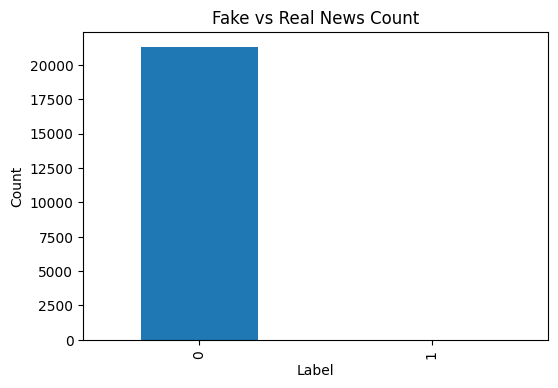

In [20]:
plt.figure(figsize=(6,4))
news['label'].value_counts().plot(kind='bar')
plt.title('Fake vs Real News Count')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()


In [21]:
fake_words = ' '.join(fake['text'].astype(str))

In [22]:
wordcloud_fake = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(fake_words)


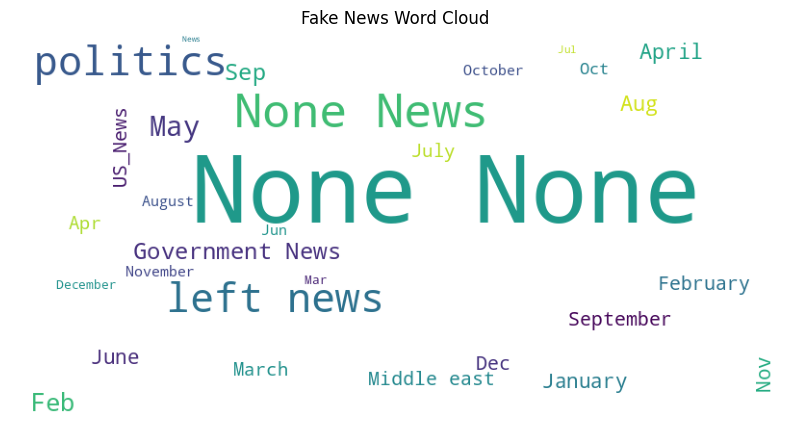

In [23]:
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_fake)
plt.axis('off')
plt.title('Fake News Word Cloud')
plt.show()


In [24]:
true_words = ' '.join(true['text'].astype(str))

In [25]:
wordcloud_true = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(true_words)


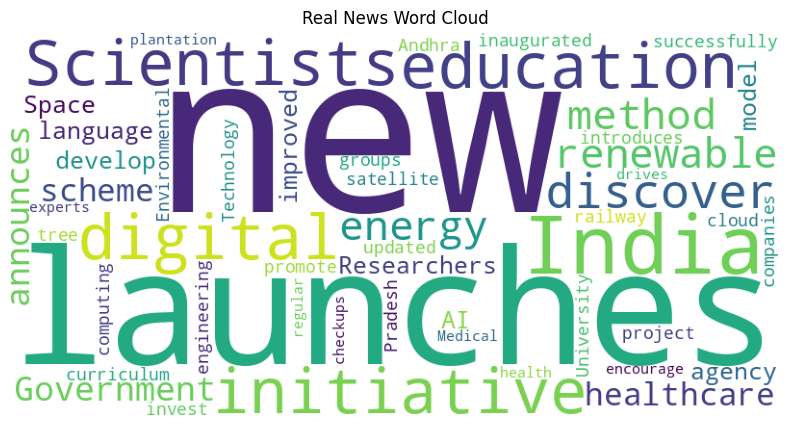

In [26]:
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_true)
plt.axis('off')
plt.title('Real News Word Cloud')
plt.show()


In [33]:
news['text'] = news['text'].fillna('')

X = news['text']
y = news['label']

In [34]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [51]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=3000
)

x_train_vectorized = vectorizer.fit_transform(
    x_train.astype(str)
)

x_test_vectorized = vectorizer.transform(
    x_test.astype(str)
)

In [52]:
model = PassiveAggressiveClassifier(max_iter=100)

model.fit(x_train_vectorized, y_train)

PassiveAggressiveClassifier(max_iter=100)

In [53]:
predictions = model.predict(x_test_vectorized)

In [54]:
score = accuracy_score(y_test, predictions)

In [55]:

print(round(score * 100, 2), '%')


99.98 %


In [56]:
cm = confusion_matrix(y_test, predictions)

In [57]:
print(cm)

[[5331    0]
 [   1    2]]


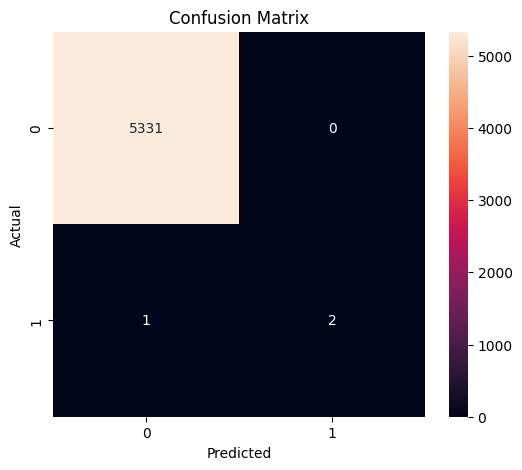

In [58]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [59]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5331
           1       1.00      0.67      0.80         3

    accuracy                           1.00      5334
   macro avg       1.00      0.83      0.90      5334
weighted avg       1.00      1.00      1.00      5334



In [62]:
news_text = input("Enter News Article : ")

Enter News Article : 75


In [63]:
input_data = vectorizer.transform([news_text])

prediction = model.predict(input_data)

In [64]:
if prediction[0] == 0:
    print("FAKE")
else:
    print("REAL")

FAKE
